# E-Commerce Customer Spending Analysis & Linear Regression

**Project Type:** Exploratory Data Analysis (EDA) + Multiple Linear Regression  
**Dataset:** E-Commerce Customers  
**Objective:** Understand which customer engagement variables are associated with annual spending and build a first predictive regression model.

---

## Business Context

An e-commerce business wants to understand customer behaviour and identify the variables most closely associated with **Yearly Amount Spent**.

The analysis focuses on four behavioural variables:

- Average Session Length
- Time on App
- Time on Website
- Length of Membership

The project follows a practical analytics workflow:

**Data Quality → EDA → Relationship Analysis → Linear Regression → Model Evaluation → Business Recommendations**

> **Note:** This is Version 1 of the regression project. Advanced regression diagnostics and statistical measures such as R², adjusted R², VIF, coefficient significance and cross-validation are intentionally reserved for a later learning iteration.


## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

pd.set_option("display.max_columns", None)


## 2. Load the Dataset

In [4]:
df_raw = pd.read_csv("data/Ecommerce Customers.csv")

df_raw.head()


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## 3. Phase 1 — Data Quality Check

In [5]:
print("Shape:", df_raw.shape)
print("Total entries:", df_raw.size)

df_raw.info()


Shape: (500, 8)
Total entries: 4000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [6]:
print("Missing values:")
display(df_raw.isna().sum())

print("Duplicate rows:", df_raw.duplicated().sum())


Missing values:


Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Duplicate rows: 0


In [7]:
df_raw.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


### Phase 1 — Conclusion

1. The dataset contains **500 rows and 8 columns**.
2. There are **4,000 total cells/entries**.
3. No missing values were identified.
4. No duplicate rows were identified.
5. The target variable for the regression model is **Yearly Amount Spent**.
6. Three columns are customer-identification/descriptive fields, while five columns are numeric.


## 4. Phase 2 — Exploratory Data Analysis

### 4.1 Outlier Check

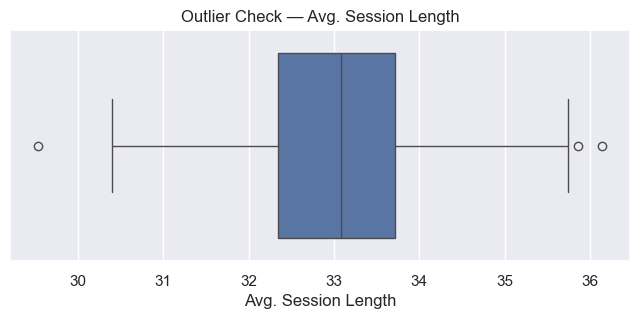

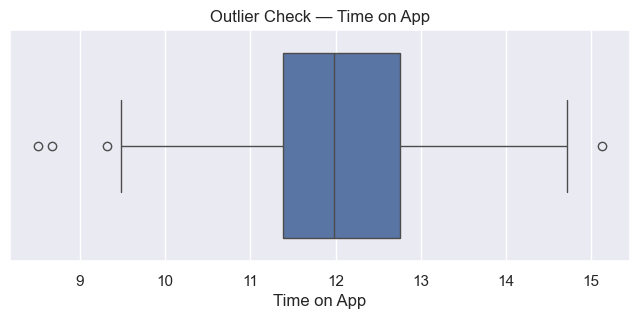

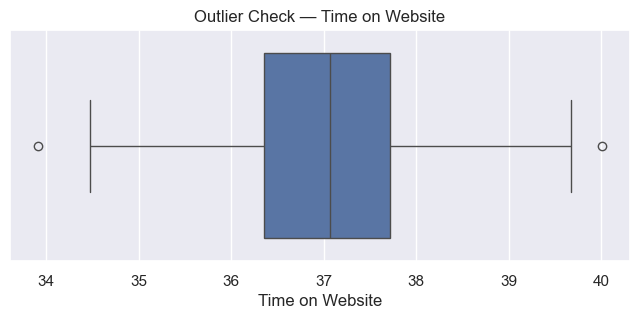

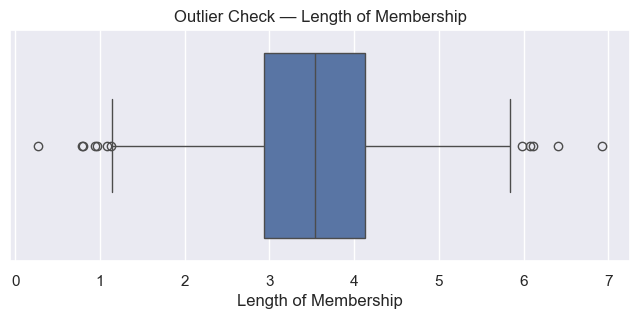

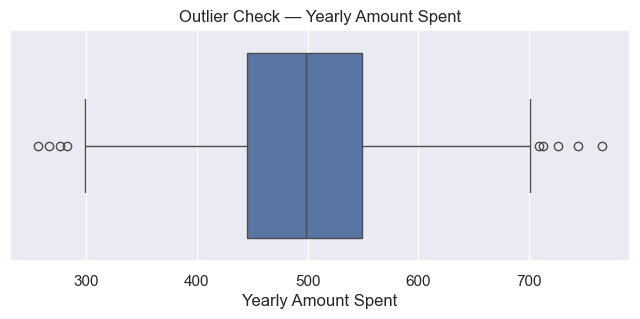

In [8]:
numeric_features = [
    "Avg. Session Length",
    "Time on App",
    "Time on Website",
    "Length of Membership",
    "Yearly Amount Spent"
]

for feature in numeric_features:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_raw[feature])
    plt.title(f"Outlier Check — {feature}")
    plt.show()


**Observation:** Several numeric variables contain observations outside the main interquartile range. These were retained rather than automatically removed because an outlier is not necessarily an error; it may represent a genuine customer observation.


### 4.2 Pairwise Relationships

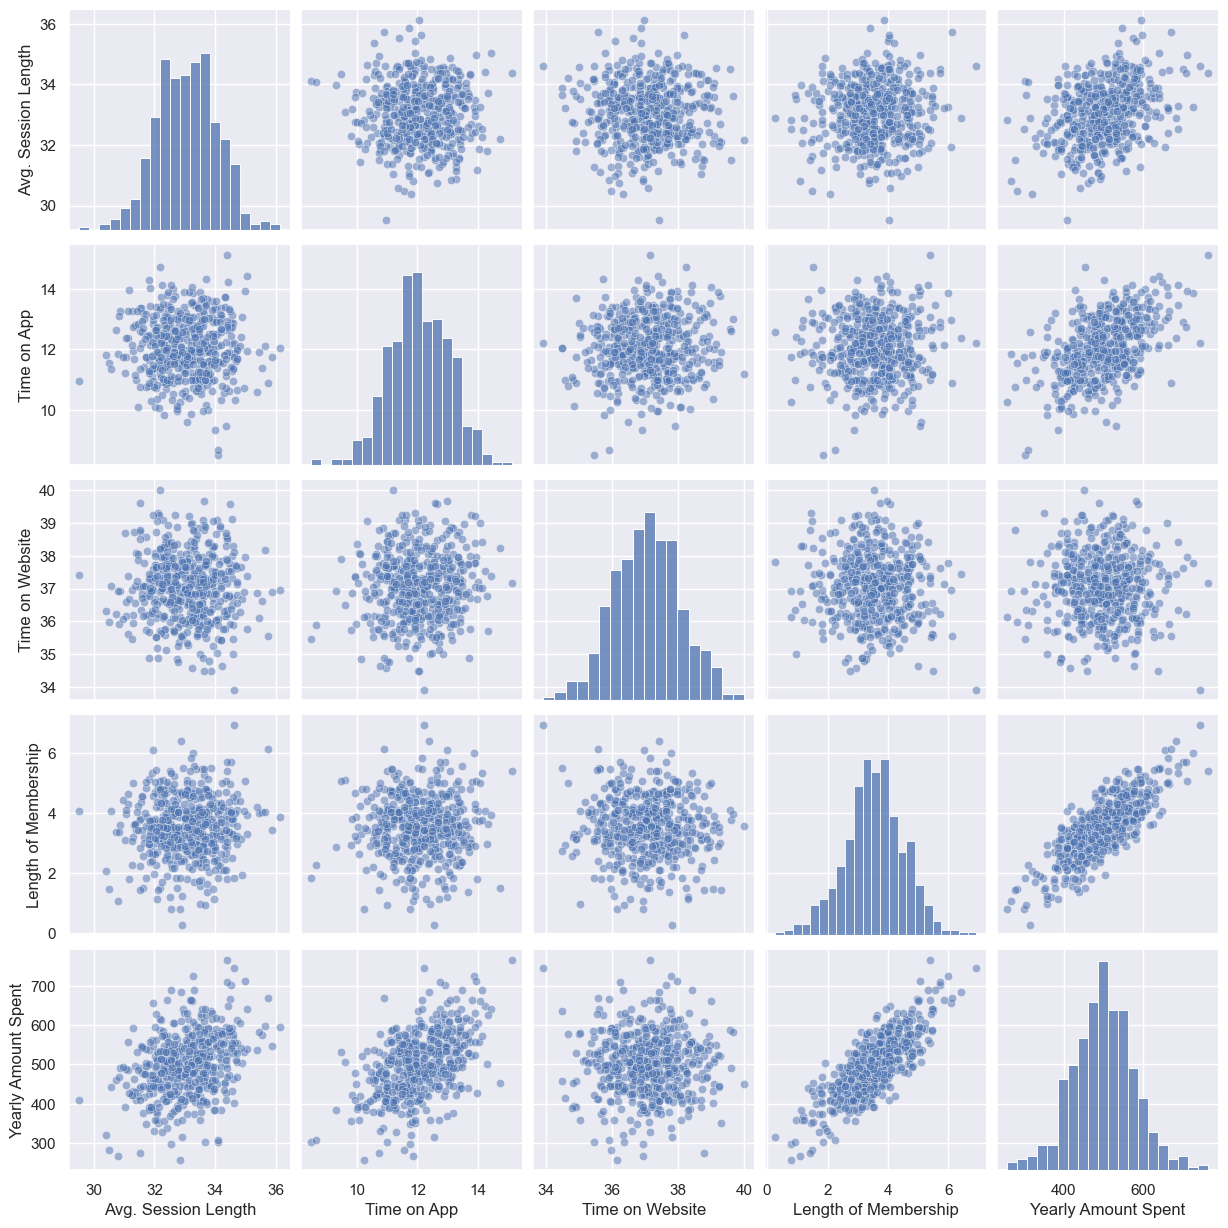

In [9]:
sns.pairplot(df_raw[numeric_features], diag_kws={"color": "C0"}, plot_kws={"alpha": 0.5})
plt.show()


The pairplot suggests that **Length of Membership** has a particularly strong positive linear relationship with Yearly Amount Spent. Time on App also shows a positive relationship, while Time on Website appears comparatively weak.


### 4.3 Correlation Analysis

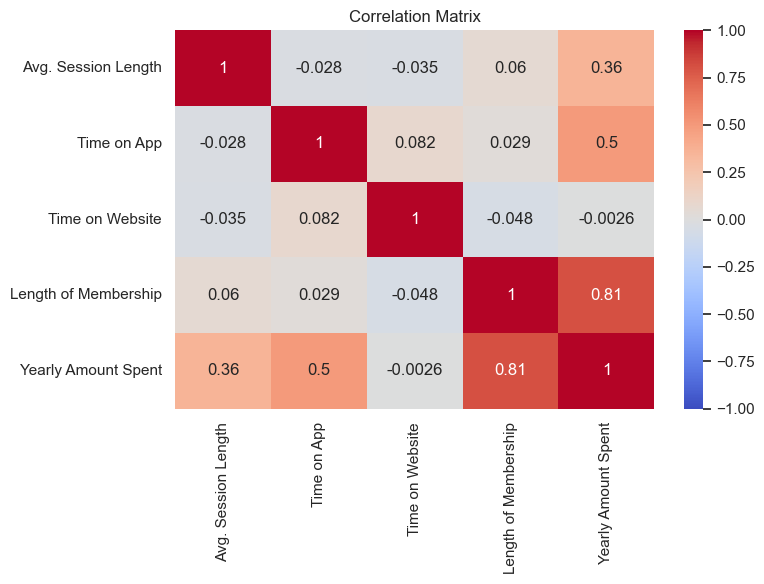

In [10]:
corr = df_raw[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


### Key correlation findings

- **Length of Membership → Yearly Amount Spent: 0.81**
- **Time on App → Yearly Amount Spent: 0.50**
- **Avg. Session Length → Yearly Amount Spent: 0.36**
- **Time on Website → Yearly Amount Spent: approximately 0**

These correlations identify candidate predictors for the regression model. Correlation indicates association, not causation.


### 4.4 Focused Relationship Plots

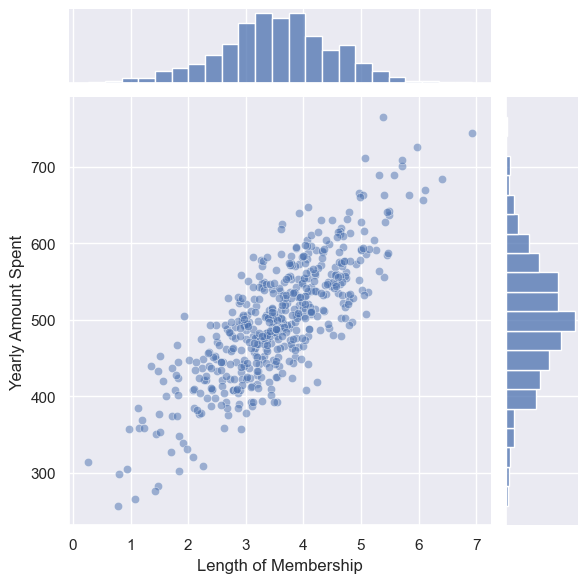

In [11]:
sns.jointplot(
    x="Length of Membership",
    y="Yearly Amount Spent",
    data=df_raw,
    alpha=0.5,
    color="C0"
)
plt.show()


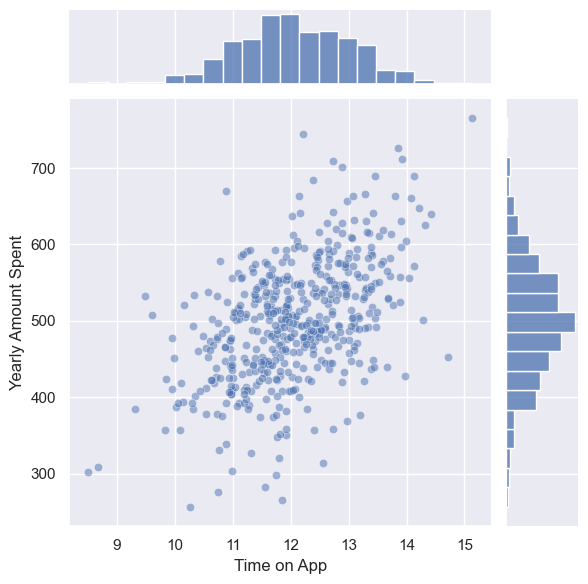

In [12]:
sns.jointplot(
    x="Time on App",
    y="Yearly Amount Spent",
    data=df_raw,
    alpha=0.5,
    color="C0"
)
plt.show()


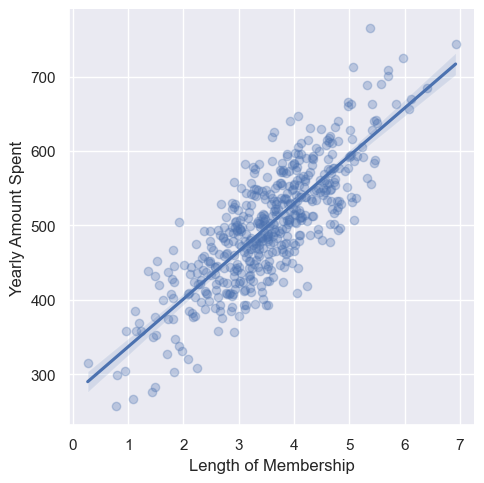

In [13]:
sns.lmplot(
    x="Length of Membership",
    y="Yearly Amount Spent",
    data=df_raw,
    scatter_kws={"alpha": 0.3}
)
plt.show()


### Phase 2 — Conclusion

1. Outliers are present in several numeric features and were retained for this first analysis.
2. Length of Membership has the strongest observed linear association with Yearly Amount Spent.
3. Time on App shows a moderate positive association with annual spend.
4. Avg. Session Length shows a weaker positive association.
5. Time on Website shows negligible linear correlation with annual spend.
6. These relationships support testing a multiple linear regression model.


## 5. Phase 3 — Multiple Linear Regression

### 5.1 Define Features and Target

**Target (y):** Yearly Amount Spent

**Features (X):**
- Avg. Session Length
- Time on App
- Time on Website
- Length of Membership


In [14]:
X = df_raw[
    [
        "Avg. Session Length",
        "Time on App",
        "Time on Website",
        "Length of Membership"
    ]
]

y = df_raw["Yearly Amount Spent"]


### 5.2 Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 350
Testing rows: 150


### 5.3 Train the Linear Regression Model

In [16]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 5.4 Model Coefficients

In [17]:
coef_df = pd.DataFrame(
    lm.coef_,
    X.columns,
    columns=["Coefficient"]
)

coef_df


,Coefficient
Avg. Session Length,25.724256
Time on App,38.597135
Time on Website,0.459148
Length of Membership,61.674732


The coefficients indicate the estimated change in Yearly Amount Spent associated with a one-unit increase in each feature, **holding the other features constant**.

In this model:

- Avg. Session Length: **25.72**
- Time on App: **38.60**
- Time on Website: **0.46**
- Length of Membership: **61.67**

The coefficient magnitude should not be treated as a definitive feature-importance ranking because the variables are measured on different scales.


### 5.5 Generate Predictions

In [18]:
predictions = lm.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)


,Actual,Predicted
0,401.033135,403.669931
1,534.777188,542.577563
2,418.602742,427.065917
3,503.978379,502.024604
4,410.069611,410.121436
5,557.608262,569.934425
6,538.941975,531.934313
7,514.336558,506.296510
8,408.620188,408.718707
9,475.015407,473.977371


### 5.6 Actual vs Predicted

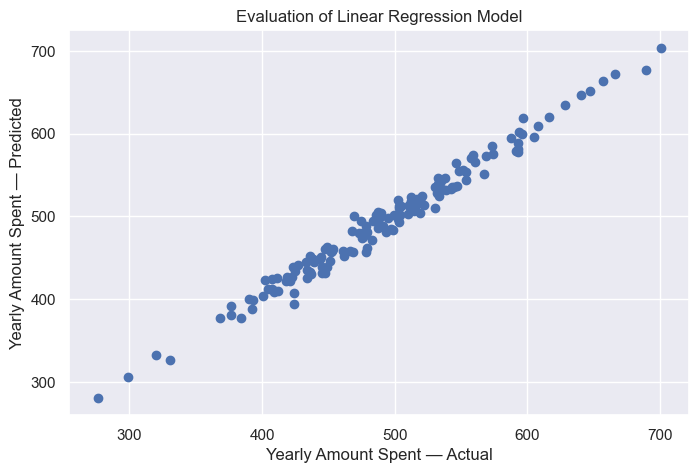

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions)
plt.xlabel("Yearly Amount Spent — Actual")
plt.ylabel("Yearly Amount Spent — Predicted")
plt.title("Evaluation of Linear Regression Model")
plt.show()


### 5.7 Model Error Metrics

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = math.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)


Mean Absolute Error: 8.426091641432038
Mean Squared Error: 103.91554136503228
Root Mean Squared Error: 10.193897260863103


### 5.8 Residual Analysis

Residual = Actual − Predicted

The residual distribution is inspected to understand how the model errors are distributed.


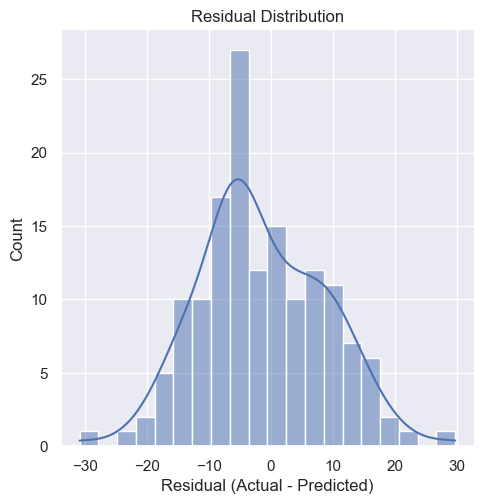

In [21]:
residuals = y_test - predictions

sns.displot(residuals, bins=20, kde=True, color="C0")
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Distribution")
plt.show()


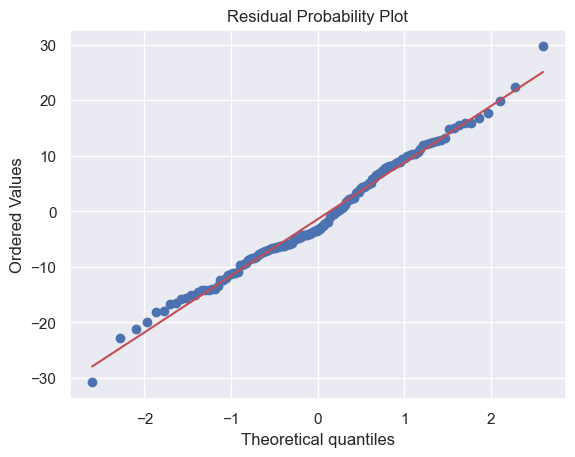

In [22]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residual Probability Plot")
plt.show()


### Phase 3 — Conclusion

The model produced:

- **MAE ≈ 8.43**
- **MSE ≈ 103.92**
- **RMSE ≈ 10.19**

The MAE indicates that the model's average absolute prediction error on the test set is approximately **8.43 spending units**. RMSE is approximately **10.19 spending units** and penalizes larger errors more heavily than MAE.

The actual-vs-predicted plot shows a strong alignment between predictions and observed values.

The residual histogram and probability plot provide an initial diagnostic view of model errors, although a complete regression validation would require additional diagnostics.


# 6. Project Conclusion & Strategic Recommendations

## What the data suggests

The analysis indicates that **Length of Membership** has the strongest observed linear association with annual customer spending, followed by **Time on App** and **Avg. Session Length**.

**Time on Website** has very little linear association with annual spending in this dataset.

## Strategic recommendations

### 1. Strengthen customer retention and loyalty
Longer membership is strongly associated with higher annual spend. A structured loyalty and retention programme could therefore be a logical business area for further investigation.

### 2. Improve the mobile app experience
Time on App has a meaningful positive association with annual spending. Improving app usability, discovery, personalization and engagement could be tested as a business hypothesis.

### 3. Investigate website engagement separately
The weak linear relationship between Time on Website and annual spending suggests that website time alone is not a strong predictor of spend. This should not be interpreted as proof that the website is unimportant; additional metrics such as conversion rate, checkout behaviour and customer journeys would be required.

## Important analytical caveat

These findings describe **associations in the dataset**. They do not prove that increasing app time or membership duration will causally increase spending. A business decision should ideally be validated through experimentation, additional data and/or causal analysis.


# 7. Next Iteration — Regression V2

The next version of this project will extend the analysis with concepts that were not yet part of this learning stage:

- R²
- Adjusted R²
- Residuals vs predicted values
- Multicollinearity / VIF
- Coefficient significance and confidence intervals
- Standardized coefficients
- Cross-validation
- Baseline comparison
- Model comparison (e.g., Ridge / Random Forest)

The purpose of V2 will be to move from **building a regression model** toward **statistically validating and comparing models**.
